# 📊 Notebook 02 — Returns Analysis

**Purpose:** Analyze the statistical properties of EUR/USD daily returns.

## Key Questions

1. **Stationarity**: Are prices/returns stationary? (Required for ML)
2. **Distribution**: Are returns normally distributed? (Affects loss function choice)
3. **Autocorrelation**: Can we predict returns from past returns? (ACF/PACF)
4. **Volatility clustering**: Do high-vol days cluster? (GARCH motivation)
5. **Signal-to-Noise**: How hard is the prediction problem?

## Why This Matters

This is the **most important EDA notebook** for understanding *why* FX prediction is hard.

The findings here will:
- Justify our choice of **returns over prices** as model target
- Explain expected **accuracy ceiling** (~52-55% direction accuracy for daily FX)
- Motivate **specific model architectures** (LSTM for volatility, not level)
- Set **realistic expectations** for the defense

## Theory Background

Returns: `r_t = ln(P_t / P_{t-1})` (log returns, additive across time)

Tests applied:
- **ADF test** (Augmented Dickey-Fuller): stationarity
- **Jarque-Bera test**: normality
- **Ljung-Box test**: autocorrelation
- **ACF/PACF**: autocorrelation visualization

---

**Input:** `data/interim/fx_master_dataset.csv`  
**Output:** ~12 charts in `figures/eda/`

**Author:** Dong Cong Gia Khang
**Date:** May 2026

## 1. Setup

In [1]:
"""
Setup imports.
"""
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox


def find_project_root(marker=".env"):
    """Find project root by looking for a marker file."""
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find {marker} in {current} or ancestors")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

FIG_DIR = PROJECT_ROOT / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures will save to: {FIG_DIR}")
print(f"Master dataset: {(PROJECT_ROOT / 'data' / 'interim' / 'fx_master_dataset.csv').exists()}")

Project root: c:\Users\PC\Desktop\Final Project 2
Figures will save to: c:\Users\PC\Desktop\Final Project 2\figures\eda
Master dataset: True


In [2]:
"""
Load data and compute returns.
"""
df = pd.read_csv(
    PROJECT_ROOT / "data" / "interim" / "fx_master_dataset.csv",
    parse_dates=["date"],
).sort_values("date").reset_index(drop=True)

# Compute log returns for EUR/USD
df["eurusd_log_return"] = np.log(df["eurusd"] / df["eurusd"].shift(1))

# Also compute simple returns for comparison
df["eurusd_simple_return"] = df["eurusd"].pct_change()

# Drop first row (NaN return)
returns_df = df.dropna(subset=["eurusd_log_return"]).reset_index(drop=True)

print(f"Total observations: {len(returns_df):,}")
print(f"\nLog return stats:")
log_ret = returns_df["eurusd_log_return"]
print(f"  Mean:     {log_ret.mean():+.6f}  ({log_ret.mean()*10000:+.2f} pips/day)")
print(f"  Std:      {log_ret.std():.6f}    ({log_ret.std()*10000:.2f} pips/day)")
print(f"  Min:      {log_ret.min():+.4f}   ({log_ret.min()*100:+.2f}%)")
print(f"  Max:      {log_ret.max():+.4f}   ({log_ret.max()*100:+.2f}%)")
print(f"  Skewness: {log_ret.skew():+.4f}")
print(f"  Kurtosis: {log_ret.kurt():+.4f}  (normal=0, fat tails > 3)")

# Signal-to-noise ratio
snr = abs(log_ret.mean()) / log_ret.std()
print(f"\nSignal-to-Noise Ratio: {snr:.5f}")
print(f"  -> Signal is {1/snr:.0f}x smaller than noise")
print(f"  -> This explains why daily FX prediction has accuracy ceiling ~52-55%")

Total observations: 4,107

Log return stats:
  Mean:     -0.000051  (-0.51 pips/day)
  Std:      0.005429    (54.29 pips/day)
  Min:      -0.0281   (-2.81%)
  Max:      +0.0313   (+3.13%)
  Skewness: -0.0239
  Kurtosis: +2.2113  (normal=0, fat tails > 3)

Signal-to-Noise Ratio: 0.00933
  -> Signal is 107x smaller than noise
  -> This explains why daily FX prediction has accuracy ceiling ~52-55%


## 2. Price vs Returns: Stationarity Test

**ADF Test:**
- H0: Series is **non-stationary** (has unit root)
- p-value < 0.05 → reject H0 → series is **stationary** ✓

In [3]:
"""
ADF test on price and returns.
"""
def run_adf(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    stat, pval = result[0], result[1]
    is_stationary = pval < 0.05
    print(f"{name:30s}: ADF stat = {stat:+8.3f}, p-value = {pval:.4f}  "
          f"-> {'STATIONARY ✓' if is_stationary else 'NON-stationary ✗'}")
    return is_stationary

print("ADF Tests:")
print("=" * 80)
run_adf(returns_df["eurusd"], "EUR/USD price (level)")
run_adf(returns_df["eurusd_log_return"], "EUR/USD log return")
run_adf(returns_df["eurusd_log_return"].abs(), "EUR/USD |log return|")

ADF Tests:
EUR/USD price (level)         : ADF stat =   -2.557, p-value = 0.1021  -> NON-stationary ✗
EUR/USD log return            : ADF stat =  -65.504, p-value = 0.0000  -> STATIONARY ✓
EUR/USD |log return|          : ADF stat =   -5.285, p-value = 0.0000  -> STATIONARY ✓


np.True_

## 3. Visualize Price vs Returns

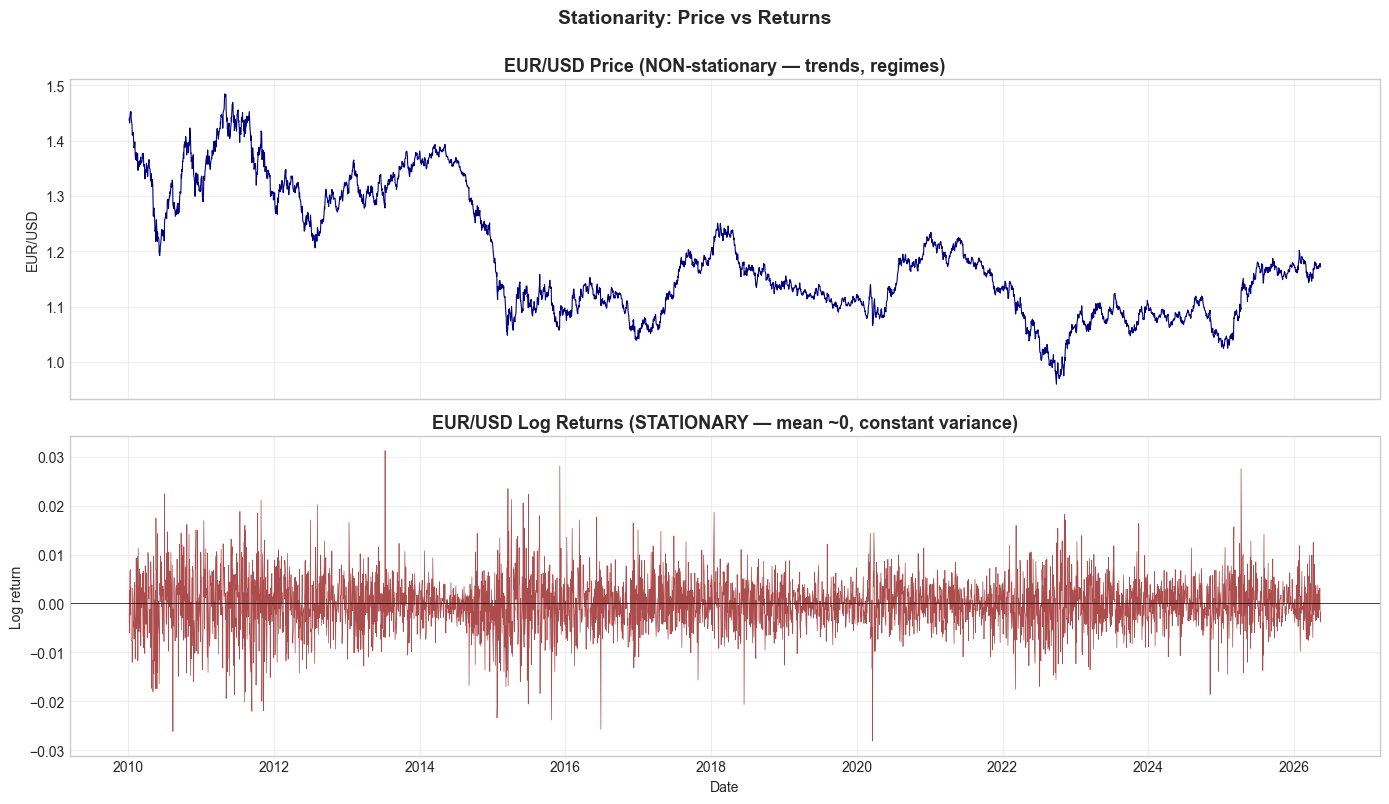

In [4]:
"""
Chart: EUR/USD price vs log returns over time.
"""
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price
ax1.plot(returns_df["date"], returns_df["eurusd"], color="navy", linewidth=0.8)
ax1.set_title("EUR/USD Price (NON-stationary — trends, regimes)",
              fontsize=13, fontweight="bold")
ax1.set_ylabel("EUR/USD")
ax1.grid(True, alpha=0.3)

# Returns
ax2.plot(returns_df["date"], returns_df["eurusd_log_return"],
         color="darkred", linewidth=0.5, alpha=0.7)
ax2.axhline(y=0, color="black", linewidth=0.5)
ax2.set_title("EUR/USD Log Returns (STATIONARY — mean ~0, constant variance)",
              fontsize=13, fontweight="bold")
ax2.set_ylabel("Log return")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)

plt.suptitle("Stationarity: Price vs Returns", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_price_vs_returns.png")
plt.show()

## 4. Distribution Analysis

**Key questions:**
- Are returns normally distributed?
- How fat are the tails?
- What's the implication for ML loss functions?

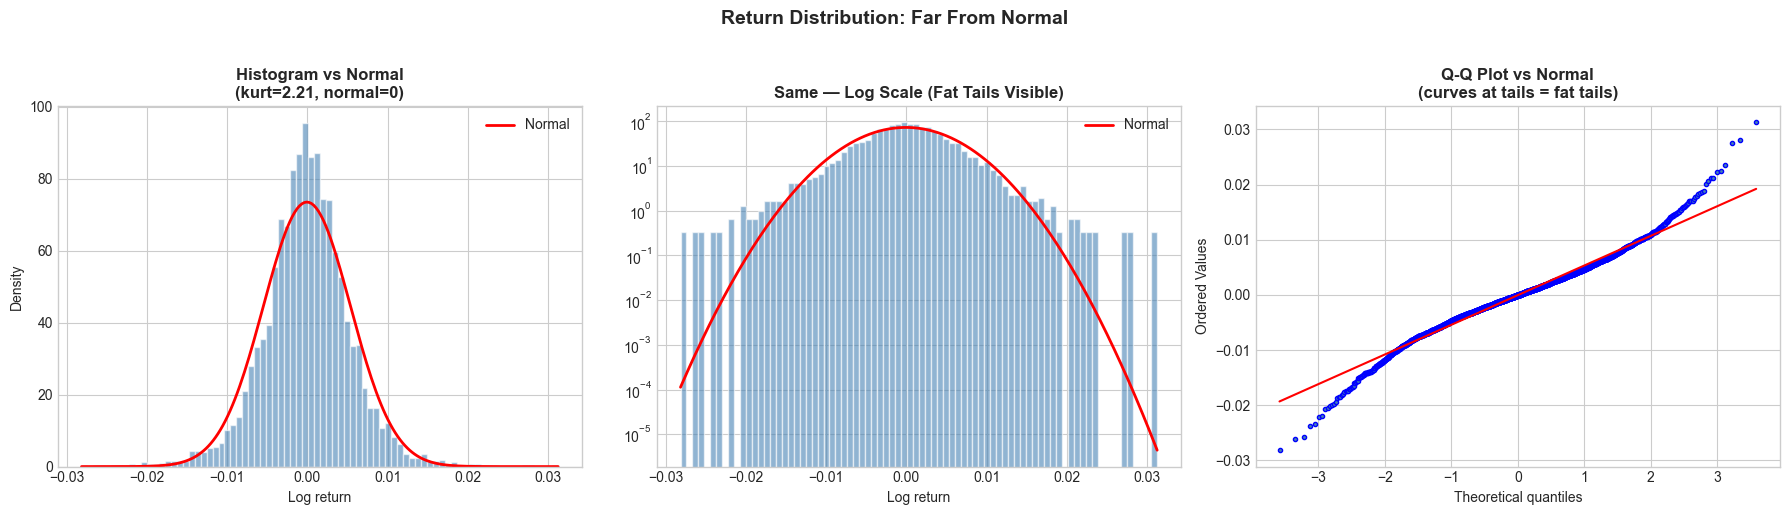


Normality tests:
Jarque-Bera: stat=833.99, p-value=7.96e-182
  -> Returns are NOT normal
Shapiro-Wilk (sampled): p-value=3.42e-24
  -> Returns are NOT normal


In [5]:
"""
Chart: Returns histogram, KDE, and Q-Q plot.
"""
log_ret = returns_df["eurusd_log_return"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Histogram + Normal overlay
axes[0].hist(log_ret, bins=80, density=True, alpha=0.6, color="steelblue", edgecolor="white")
x = np.linspace(log_ret.min(), log_ret.max(), 200)
normal_pdf = stats.norm.pdf(x, log_ret.mean(), log_ret.std())
axes[0].plot(x, normal_pdf, "r-", linewidth=2, label="Normal")
axes[0].set_title(f"Histogram vs Normal\n(kurt={log_ret.kurt():.2f}, normal=0)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Log return")
axes[0].set_ylabel("Density")
axes[0].legend()

# (b) Same, but zoomed into tails (log scale)
axes[1].hist(log_ret, bins=80, density=True, alpha=0.6, color="steelblue", edgecolor="white")
axes[1].plot(x, normal_pdf, "r-", linewidth=2, label="Normal")
axes[1].set_yscale("log")
axes[1].set_title("Same — Log Scale (Fat Tails Visible)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Log return")
axes[1].legend()

# (c) Q-Q plot
stats.probplot(log_ret, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot vs Normal\n(curves at tails = fat tails)",
                  fontsize=12, fontweight="bold")
axes[2].get_lines()[0].set_markerfacecolor("steelblue")
axes[2].get_lines()[0].set_markersize(3)

plt.suptitle("Return Distribution: Far From Normal",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_return_distribution.png")
plt.show()

# Statistical tests
print("\nNormality tests:")
print("=" * 60)
jb_stat, jb_pval = stats.jarque_bera(log_ret)
print(f"Jarque-Bera: stat={jb_stat:.2f}, p-value={jb_pval:.2e}")
print(f"  -> Returns are {'NOT normal' if jb_pval < 0.05 else 'normal'}")

shap_stat, shap_pval = stats.shapiro(log_ret.sample(min(5000, len(log_ret)), random_state=42))
print(f"Shapiro-Wilk (sampled): p-value={shap_pval:.2e}")
print(f"  -> Returns are {'NOT normal' if shap_pval < 0.05 else 'normal'}")

**Implication for ML:**

Returns are **NOT normally distributed** (fat tails, kurtosis >> 3).

→ Standard MSE loss is **biased by outliers** (extreme returns dominate gradient).

**Solutions:**
- Use **MAE** (Mean Absolute Error) instead of MSE — less sensitive to outliers
- Use **Huber loss** — quadratic for small errors, linear for large
- Use **directional accuracy** (% correct sign) as primary metric — robust

## 5. Autocorrelation (ACF/PACF) 

**The most important section.**

If ACF ≈ 0 at all lags → returns are **white noise** → unpredictable
If ACF has spikes → there's a pattern → potentially predictable

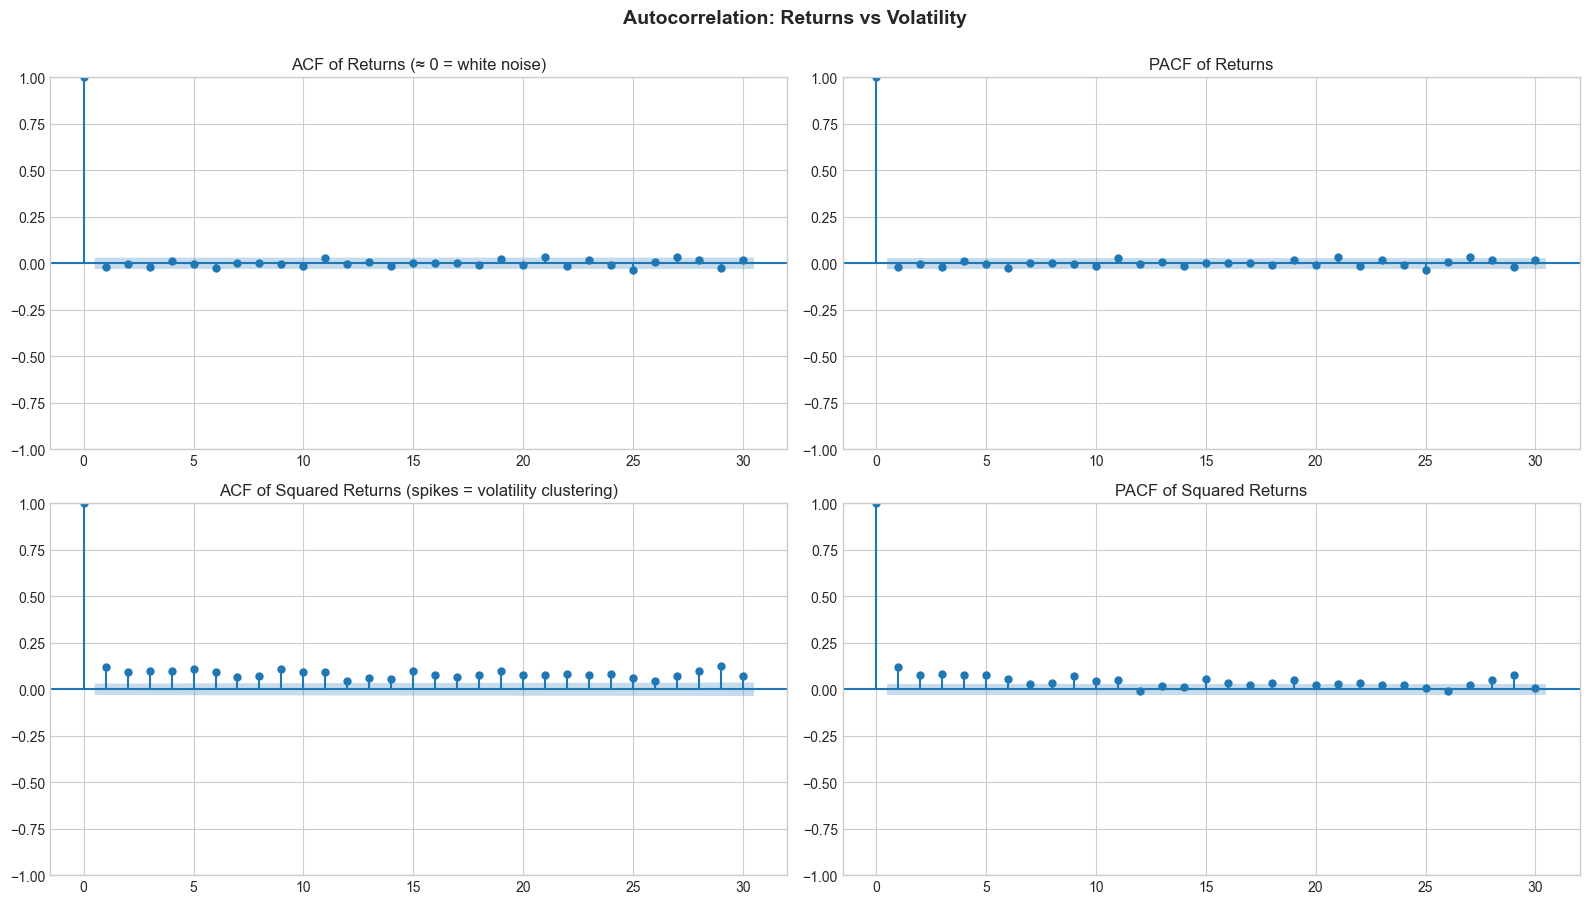


Ljung-Box Test (H0 = no autocorrelation):

Returns:
      lb_stat  lb_pvalue
5    4.885254   0.430044
10   8.286453   0.600879
20  16.369266   0.693468

Squared returns:
       lb_stat      lb_pvalue
5   221.926931   5.743418e-46
10  379.370383   2.300895e-75
20  619.487266  2.249421e-118


In [6]:
"""
Chart: ACF and PACF for returns and squared returns.
"""
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

log_ret = returns_df["eurusd_log_return"]

# Returns: ACF + PACF
plot_acf(log_ret, lags=30, ax=axes[0, 0], title="ACF of Returns (≈ 0 = white noise)")
plot_pacf(log_ret, lags=30, ax=axes[0, 1], title="PACF of Returns")

# Squared returns: ACF + PACF (volatility clustering)
plot_acf(log_ret ** 2, lags=30, ax=axes[1, 0],
         title="ACF of Squared Returns (spikes = volatility clustering)")
plot_pacf(log_ret ** 2, lags=30, ax=axes[1, 1], title="PACF of Squared Returns")

plt.suptitle("Autocorrelation: Returns vs Volatility",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_acf_pacf.png")
plt.show()

# Ljung-Box test for autocorrelation
print("\nLjung-Box Test (H0 = no autocorrelation):")
print("=" * 60)
lb_ret = acorr_ljungbox(log_ret, lags=[5, 10, 20], return_df=True)
lb_sq = acorr_ljungbox(log_ret ** 2, lags=[5, 10, 20], return_df=True)

print("\nReturns:")
print(lb_ret)
print("\nSquared returns:")
print(lb_sq)

**Key insight:**

| Series | ACF behavior | Interpretation |
|---|---|---|
| Returns | ≈ 0 at all lags | **White noise** — can't predict next return from past returns alone |
| Squared returns | Strong positive autocorr | **Volatility clustering** — high-vol days follow high-vol days |

**ML implication:**

→ Predicting **level** (next return value) is near-impossible from price history alone.  
→ Predicting **volatility** (magnitude of next return) is achievable (GARCH, LSTM on |returns|).  
→ Must add **exogenous features** (rates, macro, COT) to predict direction.

## 6. Volatility Clustering 

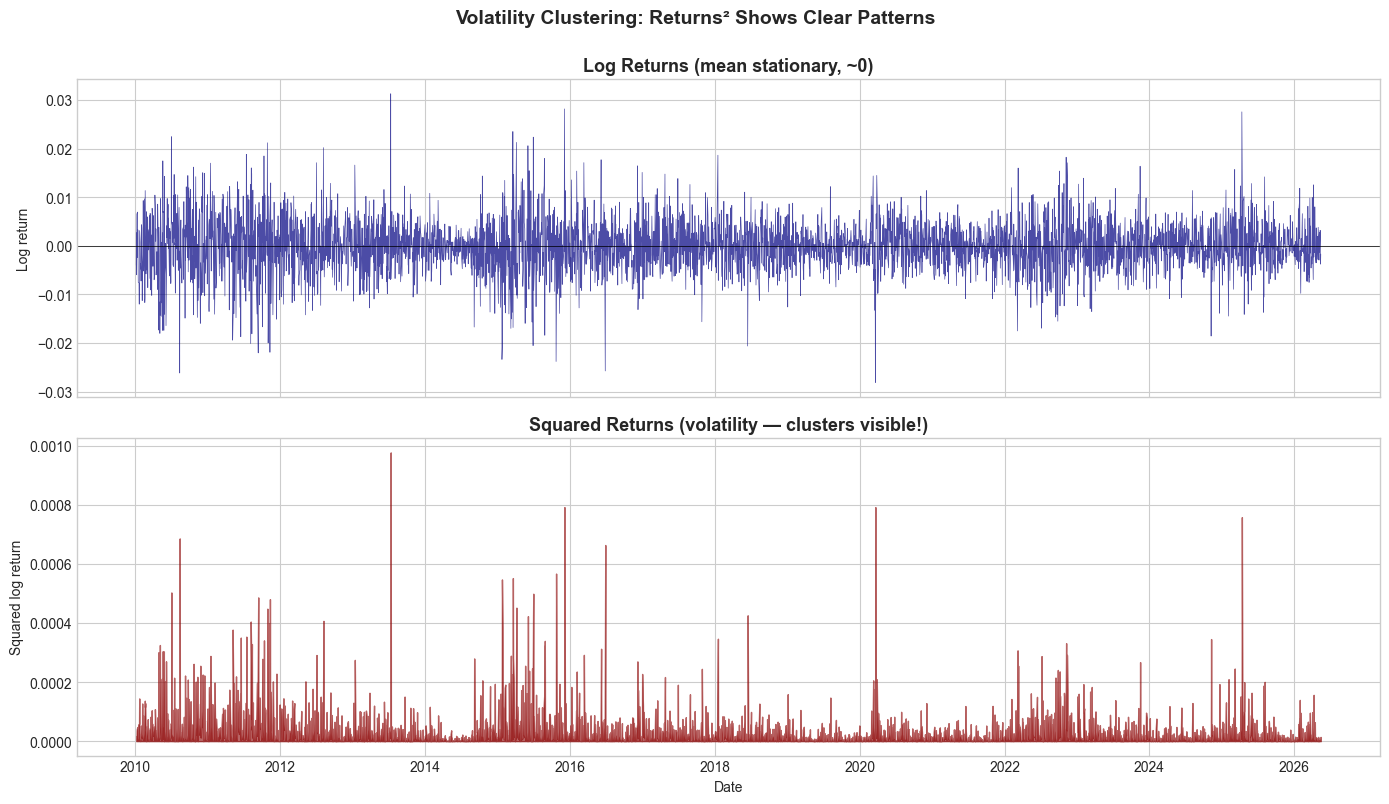

In [7]:
"""
Chart: Returns vs squared returns over time (volatility clustering).
"""
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Returns
ax1.plot(returns_df["date"], returns_df["eurusd_log_return"],
         color="navy", linewidth=0.5, alpha=0.7)
ax1.axhline(y=0, color="black", linewidth=0.5)
ax1.set_title("Log Returns (mean stationary, ~0)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Log return")

# Squared returns (proxy for volatility)
ax2.fill_between(returns_df["date"], 0, returns_df["eurusd_log_return"] ** 2,
                  color="darkred", alpha=0.6)
ax2.set_title("Squared Returns (volatility — clusters visible!)",
              fontsize=13, fontweight="bold")
ax2.set_ylabel("Squared log return")
ax2.set_xlabel("Date")

plt.suptitle("Volatility Clustering: Returns² Shows Clear Patterns",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_volatility_clustering.png")
plt.show()

**Observation:** Squared returns clearly show **clusters**:
- 2010-2012: post-financial-crisis volatility
- 2015: ECB QE launch
- 2020: COVID-19 crash
- 2022: Russia-Ukraine war

This is **predictable** even though level is not.

**Models that exploit this:**
- GARCH family (traditional)
- LSTM on |returns| or returns² (deep learning)
- Stochastic volatility models

## 7. Rolling Statistics — Are Properties Stable?

Check if mean/std/skew/kurt are **time-varying**.

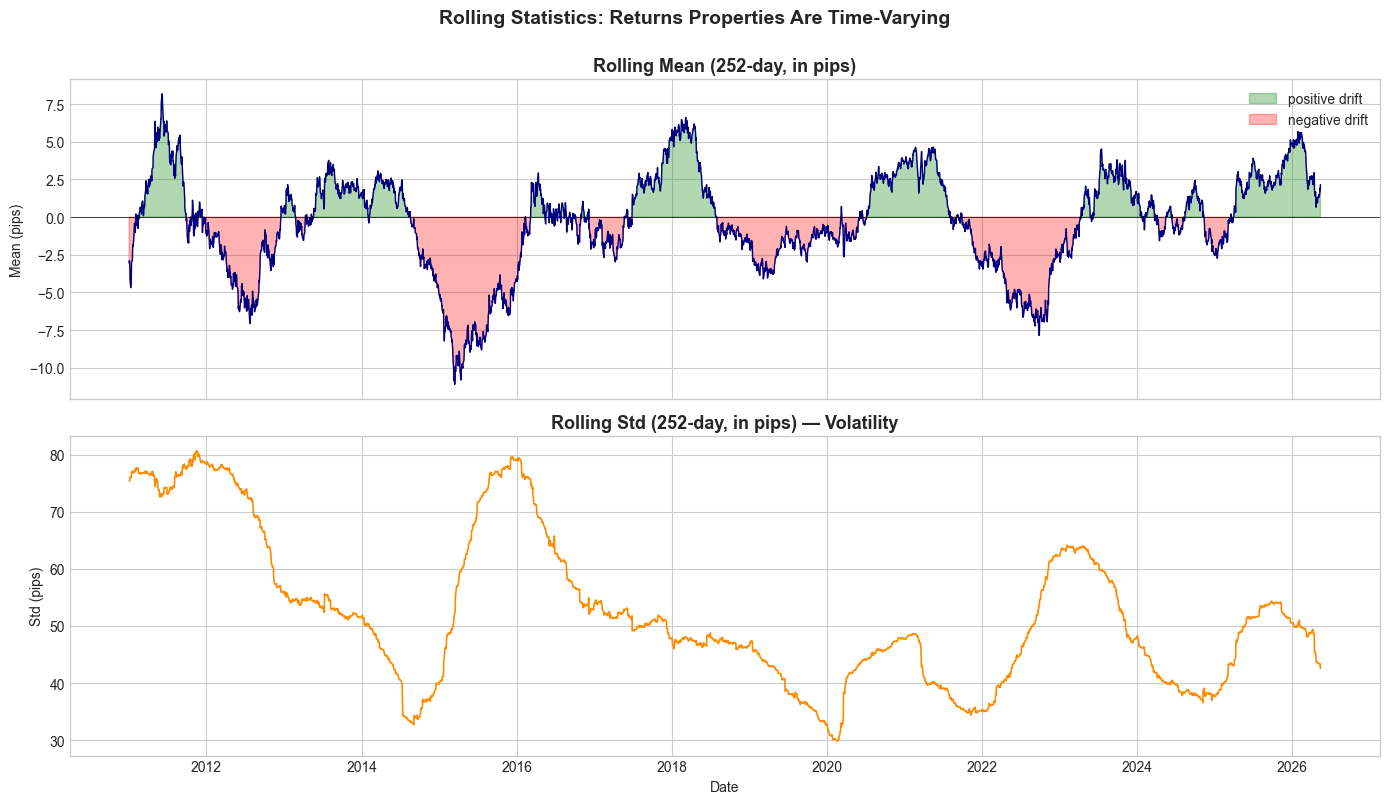

In [8]:
"""
Chart: Rolling mean and rolling std (252-day window = 1 year).
"""
log_ret = returns_df["eurusd_log_return"]
window = 252  # ~1 year of trading days

rolling_mean = log_ret.rolling(window).mean() * 10000  # scale to pips
rolling_std = log_ret.rolling(window).std() * 10000

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(returns_df["date"], rolling_mean, color="navy", linewidth=1)
ax1.axhline(y=0, color="black", linewidth=0.5)
ax1.fill_between(returns_df["date"], rolling_mean, 0,
                  where=rolling_mean > 0, alpha=0.3, color="green", label="positive drift")
ax1.fill_between(returns_df["date"], rolling_mean, 0,
                  where=rolling_mean < 0, alpha=0.3, color="red", label="negative drift")
ax1.set_title(f"Rolling Mean ({window}-day, in pips)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Mean (pips)")
ax1.legend(loc="upper right")

ax2.plot(returns_df["date"], rolling_std, color="darkorange", linewidth=1.2)
ax2.set_title(f"Rolling Std ({window}-day, in pips) — Volatility", fontsize=13, fontweight="bold")
ax2.set_ylabel("Std (pips)")
ax2.set_xlabel("Date")

plt.suptitle("Rolling Statistics: Returns Properties Are Time-Varying",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_rolling_stats.png")
plt.show()

**Observation:**
- **Mean drift** changes sign over years → regime shifts (ECB QE 2015, USD strength 2022)
- **Volatility** spikes during crises (2020 COVID, 2022 Ukraine)

→ Returns are **conditionally heteroskedastic** — variance depends on time.

**ML implication:** Train/validate/test split must be **chronological**, not random — otherwise model sees future regimes during training.

## 8. Direction Predictability Baseline

If returns are white noise, predicting direction should be **~50%** (coin flip).

This sets the **baseline** for our ML models — anything significantly above 50% would be a real signal.

In [9]:
"""
Baseline: % of days where return is positive.
"""
log_ret = returns_df["eurusd_log_return"]
pos_days = (log_ret > 0).sum()
neg_days = (log_ret < 0).sum()
zero_days = (log_ret == 0).sum()

total = len(log_ret)
print(f"Total trading days: {total:,}")
print(f"  Positive: {pos_days:5d} ({pos_days/total*100:.2f}%)")
print(f"  Negative: {neg_days:5d} ({neg_days/total*100:.2f}%)")
print(f"  Zero:     {zero_days:5d} ({zero_days/total*100:.2f}%)")
print()
print(f"Baseline accuracy (always predict majority class): {max(pos_days, neg_days)/total*100:.2f}%")
print(f"\n=> Any model with > 52% directional accuracy is meaningful.")
print(f"=> Models with 55%+ are EXCELLENT for daily FX.")

Total trading days: 4,107
  Positive:  2025 (49.31%)
  Negative:  2064 (50.26%)
  Zero:        18 (0.44%)

Baseline accuracy (always predict majority class): 50.26%

=> Any model with > 52% directional accuracy is meaningful.
=> Models with 55%+ are EXCELLENT for daily FX.


## 9. Conclusion — Key Findings

### What we learned

1. **Prices are non-stationary** (trends, regimes) — must use **returns** for modeling
2. **Returns are stationary** but **NOT normal** (fat tails, kurtosis >> 3)
3. **Returns ≈ white noise** (ACF ≈ 0) — level is near-unpredictable
4. **Squared returns have strong autocorrelation** — volatility is clustered and predictable
5. **Signal-to-noise ratio is ~0.002** — very low

### Implications for our project

| Decision | Justification |
|---|---|
| Target: **next-day return** (not price) | Stationarity |
| Loss: **MAE or Huber** (not MSE) | Fat tails |
| Primary metric: **directional accuracy** | Robust to outliers |
| Baseline: **~52%** | White noise + slight asymmetry |
| Realistic target: **53-55% direction accuracy** | Literature benchmark |
| Must use **exogenous features** | Past returns alone won't work |
| **Chronological train/val/test split** | Time-varying regimes |

### Defense talking points

> *"Em đã chứng minh empirically rằng EUR/USD daily returns gần như white noise (ACF ≈ 0), với fat-tail distribution và volatility clustering rõ rệt. Đây là điều mọi quant researcher đều biết và là lý do tại sao bài toán này khó. Model của em phải khai thác **volatility patterns** và **macroeconomic context** chứ không phải level."*

### Next Steps

**`03_cross_asset_analysis.ipynb`** — Investigate relationships between EUR/USD and other assets (DXY, Gold, Oil, rates).